# 1.dataset load




In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import os 
os.makedirs('EDA_img', exist_ok=True)
import calendar
from pandas.api.types import CategoricalDtype
from sklearn.preprocessing import StandardScaler

In [2]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")


In [3]:
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
print(df_train.shape)
print(df_test.shape)

(1460, 81)
(1459, 80)


In [5]:
df_train.shape

(1460, 81)

In [6]:
df_test.shape

(1459, 80)

In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

# most null value features 
1.ALLEY

2.fireplaceQu

3.poolQu

4.fence

5.miscfeature

In [8]:
df = pd.concat([df_train, df_test])

print("Shape of integrated Data/ DF: ",df.shape)

Shape of integrated Data/ DF:  (2919, 81)


# missing  value 

In [9]:
df.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
SalePrice       1459
FireplaceQu     1420
LotFrontage      486
GarageQual       159
GarageYrBlt      159
GarageFinish     159
GarageCond       159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrType        24
MasVnrArea        23
MSZoning           4
dtype: int64

In [10]:
int_features = df.select_dtypes(include=["int64"]).columns
print("total number of integer features :" , int_features.shape[0])  
print("integer features names:",int_features.tolist())

total number of integer features : 26
integer features names: ['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [11]:
float_features = df.select_dtypes(include=["float64"]).columns
print("total number of floating  features :" , float_features.shape[0])  
print("floating  features names:",float_features.tolist())

total number of floating  features : 12
floating  features names: ['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'SalePrice']


In [12]:
cat_features = df.select_dtypes(include=["object"]).columns
print("total number of categorical features :" , cat_features.shape[0])  
print("categorical features names:",cat_features.tolist())

total number of categorical features : 43
categorical features names: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


# handling missing value 
data cleaning work 

  visualise null/missing value 
 

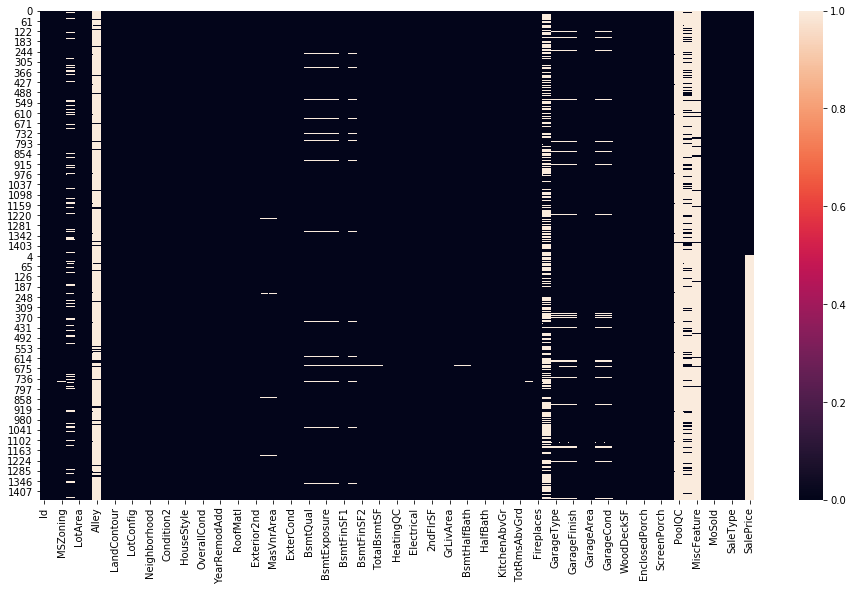

In [13]:
plt.figure(figsize=(16,9))
sns.heatmap(df.isnull())
plt.savefig("EDA_img/heatmap_DF_of_null_values.png")

# get the null value percentage for every feature

In [14]:
null_percent = df.isnull().sum()/df.shape[0]*100
null_percent

Id                0.000000
MSSubClass        0.000000
MSZoning          0.137033
LotFrontage      16.649538
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.034258
SaleCondition     0.000000
SalePrice        49.982871
Length: 81, dtype: float64

In [15]:
null_percent.sort_values(ascending=False)


PoolQC           99.657417
MiscFeature      96.402878
Alley            93.216855
Fence            80.438506
SalePrice        49.982871
                   ...    
CentralAir        0.000000
SaleCondition     0.000000
Heating           0.000000
Foundation        0.000000
Id                0.000000
Length: 81, dtype: float64

# we know that , null value remove in your domain knowledge

In [16]:
df["Alley"].value_counts()

Grvl    120
Pave     78
Name: Alley, dtype: int64


# LotFrontage =area of house 

In [17]:
df["LotFrontage"].value_counts().head()

60.0    276
80.0    137
70.0    133
50.0    117
75.0    105
Name: LotFrontage, dtype: int64

# missing_value imputation

In [18]:
missing_value_feat = null_percent[null_percent >0]
print("total missing value features =", len(missing_value_feat))

total missing value features = 35


In [19]:
missing_value_feat

MSZoning         0.137033
LotFrontage     16.649538
Alley           93.216855
Utilities        0.068517
Exterior1st      0.034258
Exterior2nd      0.034258
MasVnrType       0.822199
MasVnrArea       0.787941
BsmtQual         2.774923
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtFinType1     2.706406
BsmtFinSF1       0.034258
BsmtFinType2     2.740665
BsmtFinSF2       0.034258
BsmtUnfSF        0.034258
TotalBsmtSF      0.034258
Electrical       0.034258
BsmtFullBath     0.068517
BsmtHalfBath     0.068517
KitchenQual      0.034258
Functional       0.068517
FireplaceQu     48.646797
GarageType       5.378554
GarageYrBlt      5.447071
GarageFinish     5.447071
GarageCars       0.034258
GarageArea       0.034258
GarageQual       5.447071
GarageCond       5.447071
PoolQC          99.657417
Fence           80.438506
MiscFeature     96.402878
SaleType         0.034258
SalePrice       49.982871
dtype: float64

In [20]:
cat_na_feat = missing_value_feat[missing_value_feat.index.isin(cat_features)]
print("Total mumber of categorical missing features =" ,len(cat_na_feat))
cat_na_feat 

Total mumber of categorical missing features = 23


MSZoning         0.137033
Alley           93.216855
Utilities        0.068517
Exterior1st      0.034258
Exterior2nd      0.034258
MasVnrType       0.822199
BsmtQual         2.774923
BsmtCond         2.809181
BsmtExposure     2.809181
BsmtFinType1     2.706406
BsmtFinType2     2.740665
Electrical       0.034258
KitchenQual      0.034258
Functional       0.068517
FireplaceQu     48.646797
GarageType       5.378554
GarageFinish     5.447071
GarageQual       5.447071
GarageCond       5.447071
PoolQC          99.657417
Fence           80.438506
MiscFeature     96.402878
SaleType         0.034258
dtype: float64

In [21]:
int_na_feat = missing_value_feat[missing_value_feat.index.isin(int_features)]
print("Total mumber of interger missing features =" ,len(int_na_feat))
int_na_feat 

Total mumber of interger missing features = 0


Series([], dtype: float64)

In [22]:
float_na_feat = missing_value_feat[missing_value_feat.index.isin(float_features)]
print("Total mumber of floating missing features =" ,len(float_na_feat))
float_na_feat 

Total mumber of floating missing features = 12


LotFrontage     16.649538
MasVnrArea       0.787941
BsmtFinSF1       0.034258
BsmtFinSF2       0.034258
BsmtUnfSF        0.034258
TotalBsmtSF      0.034258
BsmtFullBath     0.068517
BsmtHalfBath     0.068517
GarageYrBlt      5.447071
GarageCars       0.034258
GarageArea       0.034258
SalePrice       49.982871
dtype: float64

In [23]:
### backup of original 
df_mvi = df.copy()
df_mvi.shape

(2919, 81)

 # handling Alley = 93.767123

In [24]:
df["Alley"].value_counts()

Grvl    120
Pave     78
Name: Alley, dtype: int64

# data pre processing ....

In [25]:
import matplotlib.pyplot as plt 
import seaborn as sns
def oldNewcountplot(df_old, df_new, features):
    plt.figure(figsize=(10,4))
    plt.subplot(121)
    sns.countplot(x=df_old[features])
    plt.title("old data distribution")
    
    plt.subplot(122)
    sns.countplot(x=df_new[features])
    plt.title("New data distribution")
    
    plt.tight_layout()
    plt.show()

In [26]:
df_new =df_mvi.copy()
df_mvi["Alley"].replace(np.nan, "NA", inplace=True)


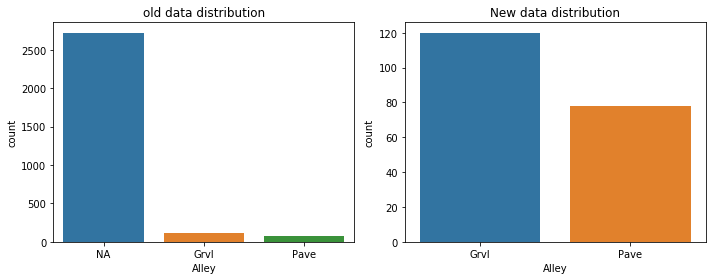

In [27]:
oldNewcountplot(df_mvi, df_new, "Alley")

# handling  LotFrontage  

In [28]:

def boxhistplot(df, figsize=(16, 5)):
    plt.figure(figsize=figsize)

    plt.subplot(121)
    sns.boxplot(x=df)
    plt.title("Boxplot")

    plt.subplot(122)
    sns.distplot(df, kde=True)
    plt.title("Histogram")

    plt.tight_layout()
    plt.show()


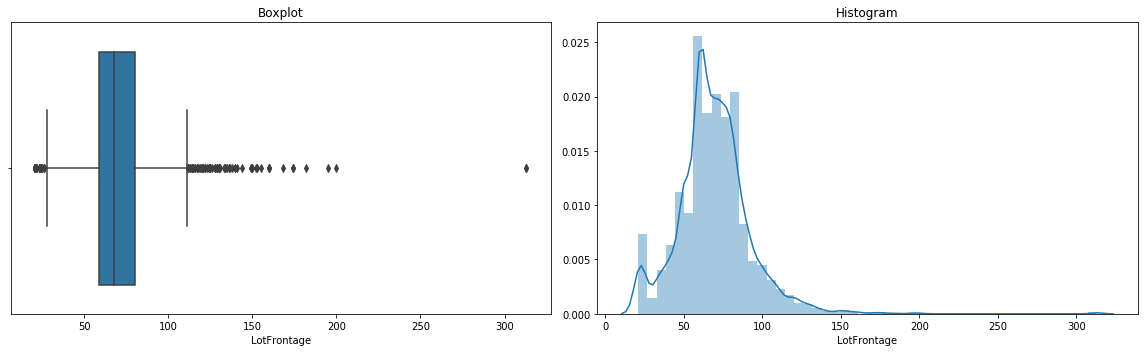

In [29]:
boxhistplot(df["LotFrontage"])

# mean fill value(nan) =LotFrontage

In [30]:
lotfrontage_mean = df["LotFrontage"].mean()
df_mvi["LotFrontage"].replace(np.nan, lotfrontage_mean, inplace=True)
df_mvi["LotFrontage"].isnull().sum()

0

# handling MasVnrType       0.547945

In [31]:
df["MasVnrType"].value_counts()



None       1742
BrkFace     879
Stone       249
BrkCmn       25
Name: MasVnrType, dtype: int64

In [32]:
MasVnrType_mode = df["MasVnrType"].mode()[0]
df_mvi["MasVnrType"].replace(np.nan, MasVnrType_mode, inplace=True)
df_mvi["MasVnrType"].isnull().sum()

0

# MasVnrArea       0.547945

In [33]:
df["MasVnrArea"].value_counts()

0.0      1738
120.0      15
176.0      13
200.0      13
216.0      12
         ... 
664.0       1
247.0       1
550.0       1
137.0       1
572.0       1
Name: MasVnrArea, Length: 444, dtype: int64

In [34]:
MasVnrType_mode = df["MasVnrArea"].mode()[0]
df_mvi["MasVnrArea"].replace(np.nan, MasVnrType_mode, inplace=True)
df_mvi["MasVnrArea"].isnull().sum()

0

In [35]:
cat_bsmt_feat = [
"BsmtQual",        
"BsmtCond",       
"BsmtExposure",     
"BsmtFinType1",    
"BsmtFinType2"
]   

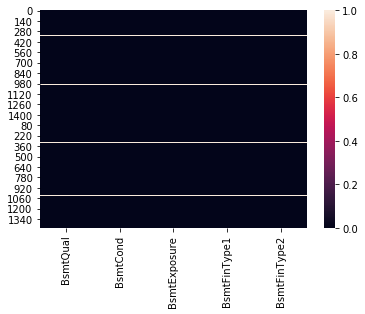

In [36]:
sns.heatmap(df[cat_bsmt_feat].isnull())

In [37]:
for feat in cat_bsmt_feat:
    print(f"Value count of{feat}: {df[feat].value_counts()}")

Value count ofBsmtQual: TA    1283
Gd    1209
Ex     258
Fa      88
Name: BsmtQual, dtype: int64
Value count ofBsmtCond: TA    2606
Gd     122
Fa     104
Po       5
Name: BsmtCond, dtype: int64
Value count ofBsmtExposure: No    1904
Av     418
Gd     276
Mn     239
Name: BsmtExposure, dtype: int64
Value count ofBsmtFinType1: Unf    851
GLQ    849
ALQ    429
Rec    288
BLQ    269
LwQ    154
Name: BsmtFinType1, dtype: int64
Value count ofBsmtFinType2: Unf    2493
Rec     105
LwQ      87
BLQ      68
ALQ      52
GLQ      34
Name: BsmtFinType2, dtype: int64


In [38]:
bsmt_cont = "NA"
for feat in cat_bsmt_feat:
    df_mvi[feat].replace(np.nan, bsmt_cont, inplace=True)

In [39]:
df_mvi[cat_bsmt_feat].isnull().sum()

BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
dtype: int64

# handling Electrical = 0.068493

In [40]:
df["Electrical"].value_counts()

SBrkr    2671
FuseA     188
FuseF      50
FuseP       8
Mix         1
Name: Electrical, dtype: int64

In [41]:
df[["Electrical"]].isnull().any(axis=1)

0       False
1       False
2       False
3       False
4       False
        ...  
1454    False
1455    False
1456    False
1457    False
1458    False
Length: 2919, dtype: bool

In [42]:
electrical_mode = df["Electrical"].mode()[0]
df_mvi["Electrical"].replace(np.nan, electrical_mode, inplace=True)
df_mvi["Electrical"].isnull().sum()

0

# handling Remaining cat features

In [43]:
other_cat_feat = ["FireplaceQu",     
"PoolQC",           
"Fence",            
"MiscFeature"]
for feat in other_cat_feat:
    print(f"value count of {feat}: {df[feat].value_counts()}")

value count of FireplaceQu: Gd    744
TA    592
Fa     74
Po     46
Ex     43
Name: FireplaceQu, dtype: int64
value count of PoolQC: Gd    4
Ex    4
Fa    2
Name: PoolQC, dtype: int64
value count of Fence: MnPrv    329
GdPrv    118
GdWo     112
MnWw      12
Name: Fence, dtype: int64
value count of MiscFeature: Shed    95
Gar2     5
Othr     4
TenC     1
Name: MiscFeature, dtype: int64


In [44]:
fireplaceQu_cont = "NA"
df_mvi["FireplaceQu"].replace(np.nan, fireplaceQu_cont, inplace=True)
df_mvi["FireplaceQu"].isnull().sum()

0

In [45]:
poolqC = "NA"
df_mvi["PoolQC"].replace(np.nan, poolqC, inplace=True)
df_mvi["PoolQC"].isnull().sum()

0

In [46]:
Fence_cont = "NA"
df_mvi["Fence"].replace(np.nan, Fence_cont, inplace=True)
df_mvi["Fence"].isnull().sum()

0

In [47]:
MiscFeature_cont = "NA"
df_mvi["MiscFeature"].replace(np.nan, MiscFeature_cont, inplace=True)
df_mvi["MiscFeature"].isnull().sum()

0

# handling Garage features

In [48]:
cat_garage_feat = [
"GarageType",      
"GarageFinish",     
"GarageQual",      
"GarageCond",
]

num_garage_feat = [
"GarageYrBlt"    
]
df_garage = df_mvi[num_garage_feat + cat_garage_feat]
df_garage[df_garage.isnull().any(axis=1)]





,GarageYrBlt,GarageType,GarageFinish,GarageQual,GarageCond
39,NaN,NaN,NaN,NaN,NaN
48,NaN,NaN,NaN,NaN,NaN
78,NaN,NaN,NaN,NaN,NaN
88,NaN,NaN,NaN,NaN,NaN
89,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1433,NaN,NaN,NaN,NaN,NaN
1449,NaN,NaN,NaN,NaN,NaN
1453,NaN,NaN,NaN,NaN,NaN
1454,NaN,NaN,NaN,NaN,NaN


In [49]:
garage_cont = "Na"
for feat in cat_garage_feat:
    df_mvi[feat].replace(np.nan, garage_cont, inplace=True)
    
    df_mvi[cat_garage_feat].isnull().sum()
    

In [50]:
garage_num = "0"
for feat in cat_garage_feat:
    df_mvi[feat].replace(np.nan, garage_num, inplace=True)
    
    df_mvi[num_garage_feat].isnull().sum()
    

In [51]:
df_mvi.isnull().any(axis=1).sum()

1540

In [52]:
df_mvi.isnull().sum().sort_values(ascending=False)

SalePrice        1459
GarageYrBlt       159
MSZoning            4
Functional          2
BsmtFullBath        2
                 ... 
1stFlrSF            0
Electrical          0
CentralAir          0
SaleCondition       0
Id                  0
Length: 81, dtype: int64

In [53]:
df_mvi["GarageYrBlt"].fillna(0, inplace=True)

In [54]:
df_mvi.isnull().any(axis=1).sum()

1459

# features transformation , hint: what exactly is this supposed to tell the model

# convert numerical features to categorical features

In [55]:
for_num_conv = ["MSSubClass", "YearBuilt", "YearRemodAdd","GarageYrBlt" "", "MoSold", "YrSold"]
for feat in for_num_conv:
    print(f"{feat}: data type = {df_mvi[feat].dtype}")

MSSubClass: data type = int64
YearBuilt: data type = int64
YearRemodAdd: data type = int64
GarageYrBlt: data type = float64
MoSold: data type = int64
YrSold: data type = int64


In [56]:
calendar.month_abbr[12]

'Dec'

In [57]:
df_mvi["MoSold"] = df_mvi["MoSold"].apply(lambda x : calendar.month_abbr[x])
df_mvi["MoSold"].unique()

array(['Feb', 'May', 'Sep', 'Dec', 'Oct', 'Aug', 'Nov', 'Apr', 'Jan',
       'Jul', 'Mar', 'Jun'], dtype=object)

In [58]:
for feat in for_num_conv:
    df_mvi[feat] = df_mvi[feat].astype(str)

In [59]:
for feat in for_num_conv:
    print(f"{feat}: = data type = {df_mvi[feat].dtype}")

MSSubClass: = data type = object
YearBuilt: = data type = object
YearRemodAdd: = data type = object
GarageYrBlt: = data type = object
MoSold: = data type = object
YrSold: = data type = object


# convert categorical features into numerical features 


 #  ORDINAL ENCODING 

In [60]:
ordinal_end_var = [
"ExterQual",
"ExterCond"
"BsmtQual",        
"BsmtCond",       
"BsmtExposure",     
"BsmtFinType1",
"BsmtFinSF1"    
"BsmtFinType2",
"HeatingQC" ,
"KitchenQual",
"FireplaceQu",
"GarageQual",
"GarageCond",
"PoolQc",
"Functional",    
"GarageFinish",
"PavedDrive",
"Utilities"
]
print ("Total number of features to convert ordinal numerical format:",  len(ordinal_end_var))
    

Total number of features to convert ordinal numerical format: 16


In [61]:
df_mvi["ExterQual"].value_counts()

TA    1798
Gd     979
Ex     107
Fa      35
Name: ExterQual, dtype: int64

In [62]:
Qual_cat = CategoricalDtype(categories = [ "Po", "Fa", "TA", "Gd", "Ex"], ordered = True)

df_mvi["ExterQual"] = df_mvi["ExterQual"].astype(Qual_cat).cat.codes

In [63]:
df_mvi["ExterQual"].value_counts()

2    1798
3     979
4     107
1      35
Name: ExterQual, dtype: int64

In [64]:
df_mvi["BsmtExposure"].isnull().sum()

0

In [65]:
df_mvi["BsmtExposure"].unique()

array(['No', 'Gd', 'Mn', 'Av', 'NA'], dtype=object)

In [66]:
df_mvi["BsmtExposure"].value_counts()

No    1904
Av     418
Gd     276
Mn     239
NA      82
Name: BsmtExposure, dtype: int64

In [67]:
df_mvi["BsmtExposure"] = df_mvi["BsmtExposure"].fillna("NA")

In [68]:
qual_cat = CategoricalDtype(categories = [ "NA", "No", "Mn", "Av", "Gd"], ordered=True)
            
df_mvi["BsmtExposure"] = df_mvi["BsmtExposure"].astype(qual_cat).cat.codes

In [69]:
df_mvi["BsmtExposure"].value_counts()

1    1904
3     418
4     276
2     239
0      82
Name: BsmtExposure, dtype: int64

In [70]:
set(df_mvi["BsmtExposure"].unique())

{0, 1, 2, 3, 4}

# ct to num

In [71]:
df_mvi.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2919 entries, 0 to 1458
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   object 
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2919 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          2919 non-null   object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC

In [72]:
df_encod = df_mvi.copy()
object_features = df_encod.select_dtypes(include="object").columns.tolist()
print("Total object data type features :", len(object_features))
print("Features: \n", object_features)

Total object data type features : 47
Features: 
 ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition']


In [73]:
df_encod[object_features].head(2)

,MSSubClass,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,NA,NA,NA,Feb,2008,WD,Normal
1,20,RL,Pave,NA,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,NA,NA,NA,May,2007,WD,Normal


In [74]:
print("Shape of DF before encoding : ", df_encod.shape)
df_encod = pd.get_dummies(df_encod,
                          columns=object_features, 
                          prefix=object_features, 
                          drop_first=True)

print("Shape of DF after encoding : ", df_encod.shape)
#ing split data for training &test

Shape of DF before encoding :  (2919, 81)
Shape of DF after encoding :  (2919, 560)


In [75]:
df_encod.select_dtypes(include="object").columns.tolist()

[]

# # split data for training &testing

In [76]:
len_train = df_train.shape[0]
len_train

1460

In [77]:
df_encod.head(2)

,Id,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,ExterQual,BsmtExposure,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,65.0,8450,7,5,196.0,3,1,706.0,0.0,...,0,0,0,0,1,0,0,0,1,0
1,2,80.0,9600,6,8,0.0,2,4,978.0,0.0,...,0,0,0,0,1,0,0,0,1,0


In [78]:
df_encod[:len_train]

,Id,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,ExterQual,BsmtExposure,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,65.0,8450,7,5,196.0,3,1,706.0,0.0,...,0,0,0,0,1,0,0,0,1,0
1,2,80.0,9600,6,8,0.0,2,4,978.0,0.0,...,0,0,0,0,1,0,0,0,1,0
2,3,68.0,11250,7,5,162.0,3,2,486.0,0.0,...,0,0,0,0,1,0,0,0,1,0
3,4,60.0,9550,7,5,0.0,2,1,216.0,0.0,...,0,0,0,0,1,0,0,0,0,0
4,5,84.0,14260,8,5,350.0,3,3,655.0,0.0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,62.0,7917,6,5,0.0,2,1,0.0,0.0,...,0,0,0,0,1,0,0,0,1,0
1456,1457,85.0,13175,6,6,119.0,2,1,790.0,163.0,...,0,0,0,0,1,0,0,0,1,0
1457,1458,66.0,9042,7,9,0.0,4,1,275.0,0.0,...,0,0,0,0,1,0,0,0,1,0
1458,1459,68.0,9717,5,6,0.0,2,2,49.0,1029.0,...,0,0,0,0,1,0,0,0,1,0


In [79]:
y = df["SalePrice"]

In [80]:
x = df.drop("SalePrice", axis=1)

In [81]:
x_encod = pd.get_dummies(x, drop_first=True)
                         

In [82]:
type(x_encod)

pandas.core.frame.DataFrame

In [83]:
x_encod.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706.0,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978.0,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486.0,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216.0,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655.0,...,0,0,0,0,1,0,0,0,1,0


In [84]:
x_train = df_encod[:len_train].drop("SalePrice" , axis=1)
y_train = df_encod["SalePrice"][:len_train]
x_test  = df_encod[len_train:].drop("SalePrice", axis=1)

print("Shape of x_train data :", x_train.shape ) 
print("Shape of y_train data :", y_train.shape ) 
print("Shape of x_test data :" , x_test.shape ) 

Shape of x_train data : (1460, 559)
Shape of y_train data : (1460,)
Shape of x_test data : (1459, 559)


# feature scaling

In [85]:
sc = StandardScaler()
sc.fit(x_train)

# formula z = (x-u)/s

x_train = sc.transform(x_train)
x_test = sc.transform(x_test)

In [86]:
x_train[:3,:]

array([[-1.73086488, -0.22335706, -0.20714171, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-1.7284922 ,  0.45789401, -0.09188637, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-1.72611953, -0.08710685,  0.07347998, ..., -0.11785113,
         0.4676514 , -0.30599503]])

In [87]:
x_train[:3,:]

array([[-1.73086488, -0.22335706, -0.20714171, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-1.7284922 ,  0.45789401, -0.09188637, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-1.72611953, -0.08710685,  0.07347998, ..., -0.11785113,
         0.4676514 , -0.30599503]])

In [88]:
### carry forward for deployment
#sc.mean_
#sc.n_features
#sc.n_samples_seen_
#sc.scale_
#sc.var_
#sc.with_mean
#sc.with_std

In [89]:
import sys
!{sys.executable} -m pip install xgboost --prefer-binary

In [90]:
import xgboost
print(xgboost.__version__)

1.6.2


# train ml model

In [91]:
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression 
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.isotonic import IsotonicRegression

from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor


In [92]:
svr = SVR()
lr =  LinearRegression()
sgdr =  LinearRegression()
knr = KNeighborsRegressor()
gpr = GaussianProcessRegressor()
dtr = DecisionTreeRegressor()
gbr = GradientBoostingRegressor()
rfr = RandomForestRegressor()
xgbr = XGBRegressor()

mlpr = MLPRegressor()
ir = IsotonicRegression()

# dictionary create 

In [93]:
models = {"a":["LinearRegression", lr],                    
          "b":["SVR", svr],
          "c":["SGDRegressor", sgdr],
          "d":["KNeighborsRegressor", knr],
          "e":["GaussianProcessRegressor", gpr],
          "f":["DecisionTreeRegressor", dtr],
          "g":["GradientBoostingRegressor", gbr],
          "h":["RandomForestRegressor", rfr],
          "i":["XGBRegressor", xgbr],
          "j":["MLPRegressor", mlpr],
          "k":["IsotonicRegression", ir]
         }

In [94]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, r2_score

def test_model(model, X_train, y_train):
    cv = KFold(n_splits = 7, shuffle=True, random_state = 42)
    r2 = make_scorer(r2_score)
    r2_val_score = cross_val_score(model, X_train, y_train, cv=cv, scoring = r2)
    score = [r2_val_score.mean()]
    return score
    

In [95]:
models_score = []
for model in models:
    print("Training model :", models[model][0])
    score = test_model(models[model][1], x_train, y_train)
    print("score of model : ", score)
    models_score.append([models[model][0], score[0]])

Training model : LinearRegression
score of model :  [-1.6624517309094892e+25]
Training model : SVR
score of model :  [-0.05591443470460627]
Training model : SGDRegressor
score of model :  [-1.6624517309094892e+25]
Training model : KNeighborsRegressor
score of model :  [0.5766619621626409]
Training model : GaussianProcessRegressor
score of model :  [-5.3385852730254415]
Training model : DecisionTreeRegressor
score of model :  [0.6677772785731299]
Training model : GradientBoostingRegressor
score of model :  [0.8436889334245153]
Training model : RandomForestRegressor
score of model :  [0.8440915581676393]
Training model : XGBRegressor
score of model :  [0.8152548058632859]
Training model : MLPRegressor


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:571: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:571: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:571: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:571: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  % self.max_iter, Conv

score of model :  [-4.710204114028614]
Training model : IsotonicRegression
score of model :  [nan]


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:571: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: X should be a 1d array

  FitFailedWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: X should be a 1d array

  FitFailedWarning)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set t

# hurry..... score of model :  0.8433738396403062 randomforest(accurace)


# score of model :  [0.8421896748887197] GradientBoostingRegressor (accurace)


In [96]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
        'n_estimators':[100],
         'max_depth': [None,10],
}
grid = GridSearchCV(
        rf,
        param_grid,
        cv=3,
        scoring='r2',
        n_jobs=1
)
grid.fit(x_train, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}
Best CV score: 0.8505928291683943


# present solution

In [97]:
best_model = grid.best_estimator_

best_model.fit(x_train, y_train)

RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=42, verbose=0, warm_start=False)

In [98]:
best_model = grid.best_estimator_

# Real result

In [99]:
type(x_train), type(x_test)

(numpy.ndarray, numpy.ndarray)

In [100]:
best_model.fit(x_train,y_train)

RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=42, verbose=0, warm_start=False)

In [101]:
np.isnan(x_test).sum()

10

In [102]:
x_test = np.nan_to_num(x_test)

In [103]:
x_test.shape

(1459, 559)

In [104]:
final_pred = best_model.predict(x_test)

In [105]:
type(final_pred), final_pred.shape

(numpy.ndarray, (1459,))

In [106]:
final_pred[:5]

array([129414.87, 159584.25, 180648.24, 181461.  , 199472.69])

In [107]:
x_test.shape

(1459, 559)

In [108]:
submission = pd.DataFrame({
    "Id": df_test["Id"],
    "SalePrice": final_pred
})

In [109]:
submission.to_csv("final_output.csv", index=False)